# DREAM5 EDA — B-JEPA Project

This notebook characterises all four DREAM5 networks used in the B-JEPA experiments:

| ID | Name | Primary role |
|----|------|--------------|
| net1 | In silico | Development / sanity-check (known ground truth) |
| net2 | *S. aureus* | Secondary biological benchmark |
| net3 | *E. coli* | **Primary benchmark** (DREAM5 canonical) |
| net4 | *S. cerevisiae* | Eukaryotic stress-test |

Sections:
1. Dataset inventory
2. Expression matrix statistics (distributions, variance, missingness)
3. TF vs non-TF expression profiles
4. Gold standard sparsity and edge statistics
5. TF–target correlation structure
6. Dimensionality reduction (PCA)
7. Summary table for paper

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from bjepa.data import load_network

DATA_DIR = ROOT / 'data'
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Load all networks

In [2]:
nets = {i: load_network(DATA_DIR, i) for i in [1, 2, 3, 4]}

inventory = []
for nid, net in nets.items():
    inventory.append({
        'Network': f'net{nid} ({net.name})',
        'Samples': net.n_samples,
        'Genes': net.n_genes,
        'TFs': net.n_tfs,
        'Non-TF genes': net.n_genes - net.n_tfs,
        'Evaluated edges': net.n_evaluated_edges,
        'Positive edges': net.n_positive_edges,
        'Sparsity (pos/TF×gene)': f'{net.sparsity:.4%}',
        'Gold standard': net.gold_standard is not None,
    })

pd.DataFrame(inventory).set_index('Network')

,Samples,Genes,TFs,Non-TF genes,Evaluated edges,Positive edges,Sparsity (pos/TF×gene),Gold standard
Network,,,,,,,,
net1 (in_silico),805,1643,195,1448,278392,4012,1.2522%,True
net2 (s_aureus),160,2810,99,2711,278091,428,0.1539%,True
net3 (e_coli),805,4511,334,4177,152280,2066,0.1371%,True
net4 (s_cerevisiae),536,5950,333,5617,227202,3940,0.1989%,True


## 2. Expression matrix statistics

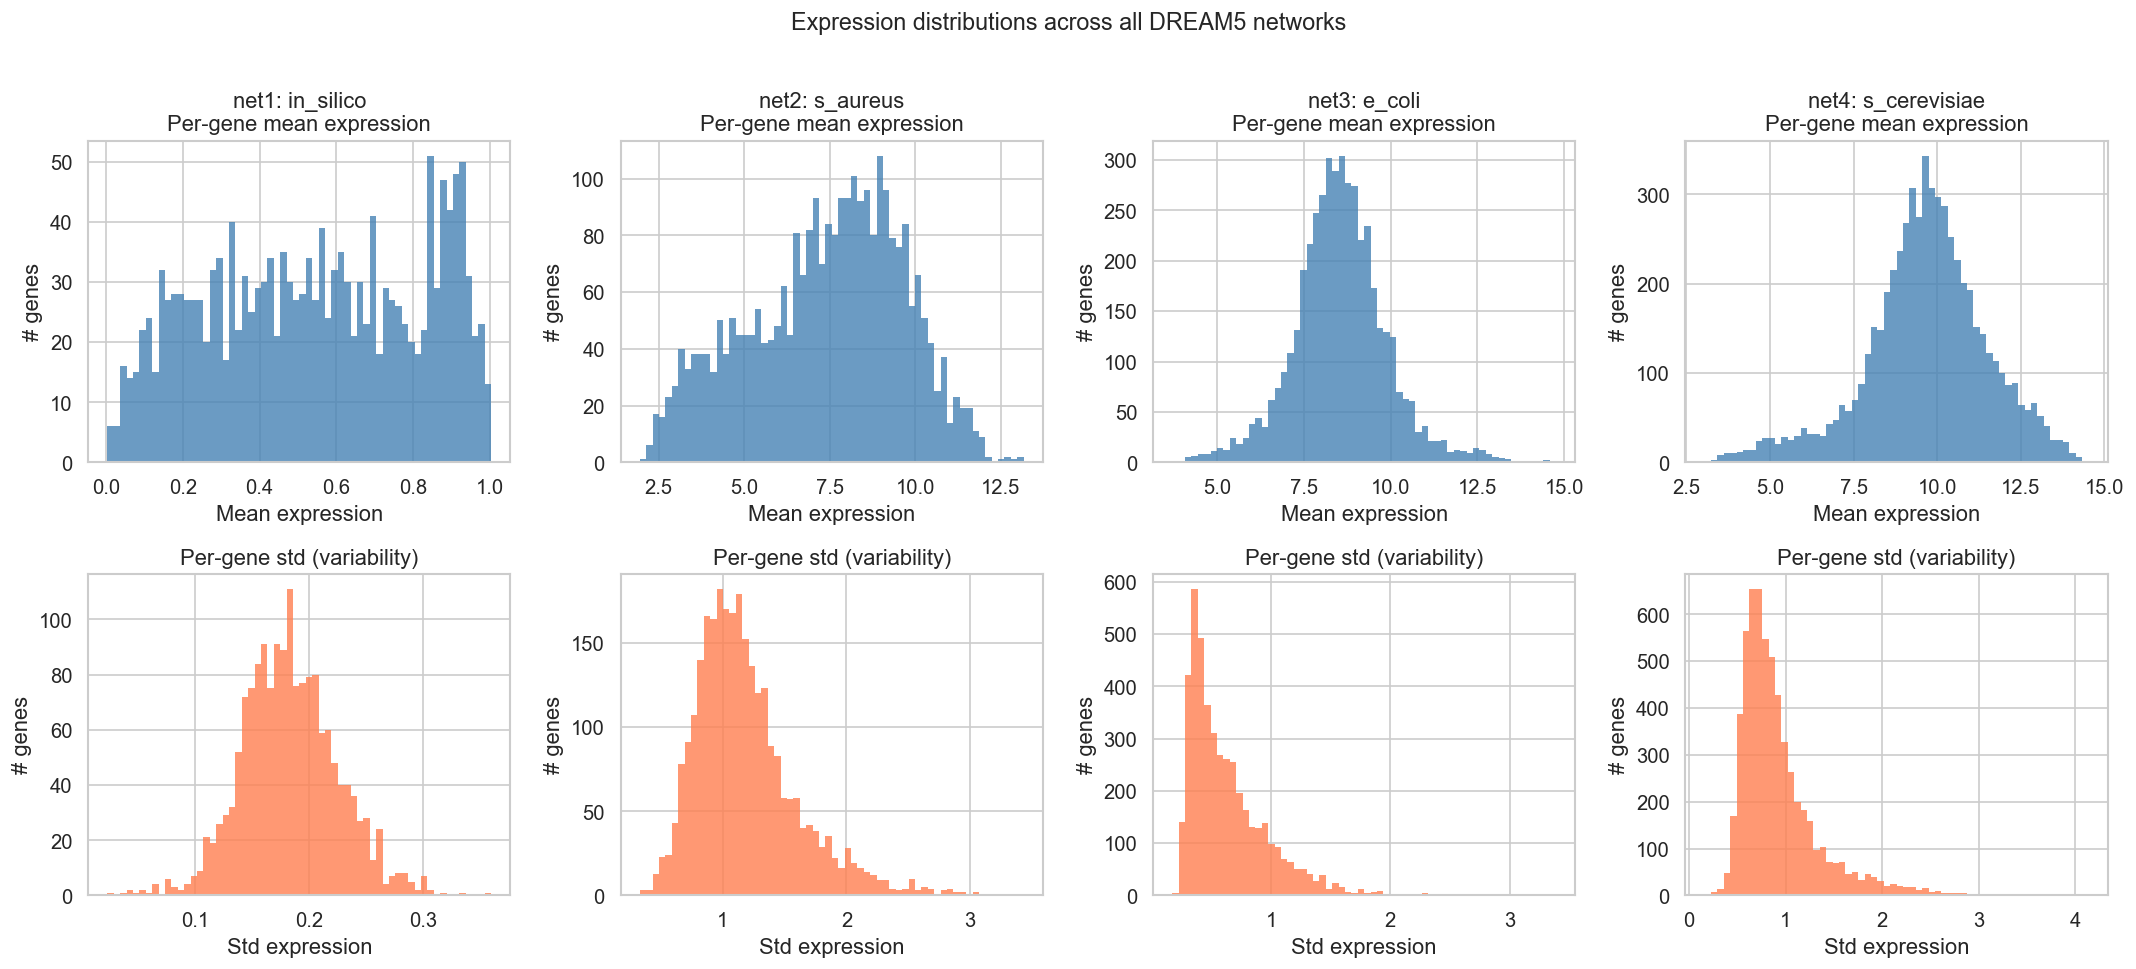

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Expression distributions across all DREAM5 networks', fontsize=14, y=1.01)

for col_idx, (nid, net) in enumerate(nets.items()):
    vals = net.expression.values.ravel()
    
    # Top row: per-gene mean expression histogram
    ax = axes[0, col_idx]
    gene_means = net.expression.mean(axis=0)
    ax.hist(gene_means, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_title(f'net{nid}: {net.name}\nPer-gene mean expression')
    ax.set_xlabel('Mean expression')
    ax.set_ylabel('# genes')
    
    # Bottom row: per-gene std histogram
    ax = axes[1, col_idx]
    gene_stds = net.expression.std(axis=0)
    ax.hist(gene_stds, bins=60, color='coral', alpha=0.8, edgecolor='none')
    ax.set_title('Per-gene std (variability)')
    ax.set_xlabel('Std expression')
    ax.set_ylabel('# genes')

plt.tight_layout()
plt.show()

In [4]:
# Summary stats per network
summary_rows = []
for nid, net in nets.items():
    vals = net.expression.values
    gene_vars = vals.var(axis=0)
    summary_rows.append({
        'Network': f'net{nid}',
        'Global mean': f'{vals.mean():.3f}',
        'Global std': f'{vals.std():.3f}',
        'Global min': f'{vals.min():.3f}',
        'Global max': f'{vals.max():.3f}',
        'Median gene var': f'{np.median(gene_vars):.3f}',
        'Missing values': int(np.isnan(vals).sum()),
        'Near-zero var genes (var<0.01)': int((gene_vars < 0.01).sum()),
    })
pd.DataFrame(summary_rows).set_index('Network')

,Global mean,Global std,Global min,Global max,Median gene var,Missing values,Near-zero var genes (var<0.01)
Network,,,,,,,
net1,0.543,0.331,0.000,2.197,0.033,0,32
net2,7.394,2.574,1.336,14.101,1.229,0,0
net3,8.544,1.519,3.460,15.281,0.282,0,0
net4,9.661,2.095,2.382,14.924,0.659,0,0


## 3. TF vs non-TF expression profiles

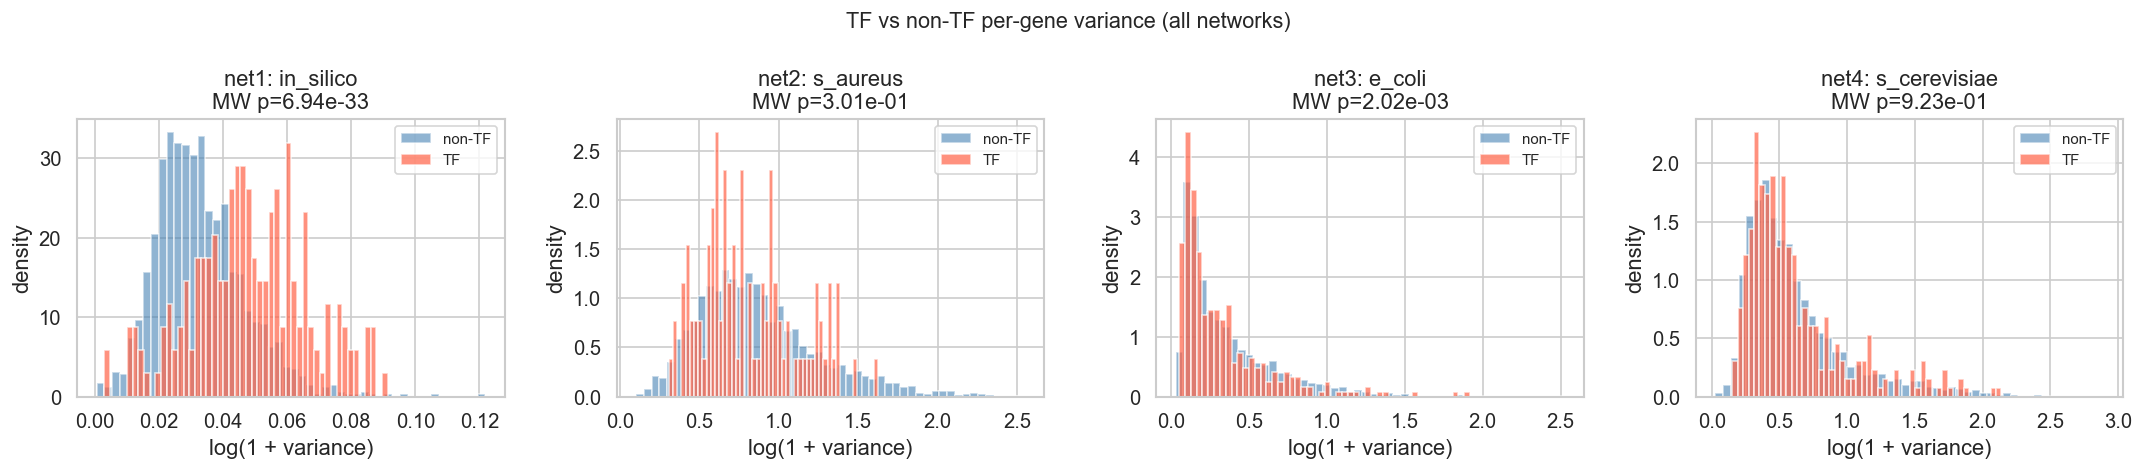

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('TF vs non-TF per-gene variance (all networks)', fontsize=13)

for ax, (nid, net) in zip(axes, nets.items()):
    tf_set = set(net.tf_ids)
    gene_vars = net.expression.var(axis=0)
    tf_vars   = gene_vars[[g for g in net.gene_ids if g in tf_set]]
    notf_vars = gene_vars[[g for g in net.gene_ids if g not in tf_set]]
    
    ax.hist(np.log1p(notf_vars), bins=50, alpha=0.6, label='non-TF', color='steelblue', density=True)
    ax.hist(np.log1p(tf_vars),   bins=50, alpha=0.7, label='TF',     color='tomato',    density=True)
    ax.set_title(f'net{nid}: {net.name}')
    ax.set_xlabel('log(1 + variance)')
    ax.set_ylabel('density')
    ax.legend(fontsize=9)
    
    # Mann-Whitney test
    stat, p = stats.mannwhitneyu(tf_vars, notf_vars, alternative='two-sided')
    ax.set_title(f'net{nid}: {net.name}\nMW p={p:.2e}')

plt.tight_layout()
plt.show()

## 4. Gold standard: sparsity and degree distribution

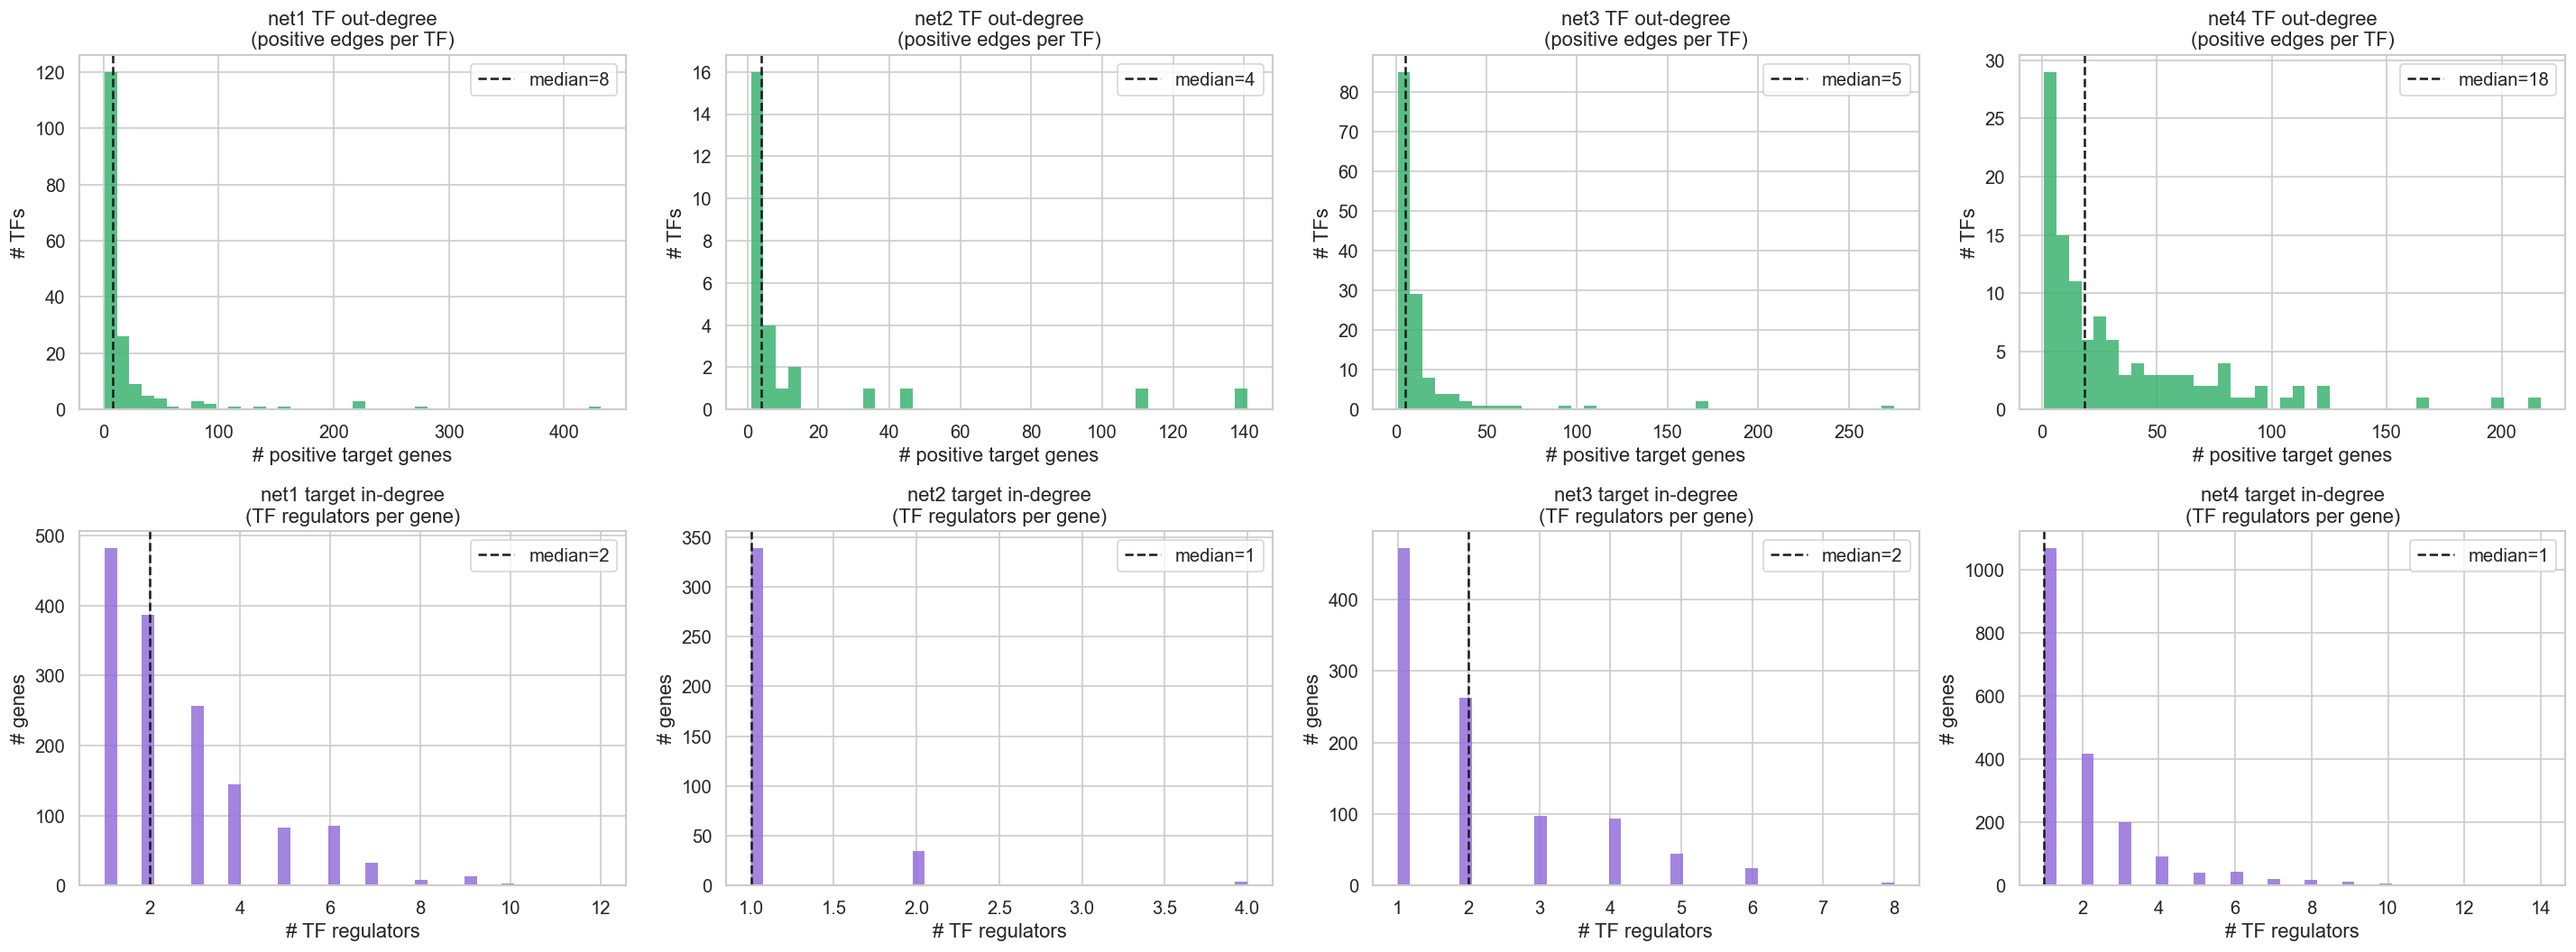

In [6]:
# Networks with gold standards
gs_nets = {nid: net for nid, net in nets.items() if net.gold_standard is not None}

fig, axes = plt.subplots(2, len(gs_nets), figsize=(6 * len(gs_nets), 9))
if len(gs_nets) == 1:
    axes = axes.reshape(2, 1)

for col, (nid, net) in enumerate(gs_nets.items()):
    gs = net.gold_standard
    pos = gs[gs['label'] == 1]
    
    # TF out-degree (# positive targets per TF)
    ax = axes[0, col]
    out_deg = pos.groupby('tf').size()
    ax.hist(out_deg, bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
    ax.axvline(out_deg.median(), color='k', ls='--', label=f'median={out_deg.median():.0f}')
    ax.set_title(f'net{nid} TF out-degree\n(positive edges per TF)')
    ax.set_xlabel('# positive target genes')
    ax.set_ylabel('# TFs')
    ax.legend()
    
    # Target gene in-degree (# TFs regulating each gene)
    ax = axes[1, col]
    in_deg = pos.groupby('target').size()
    ax.hist(in_deg, bins=40, color='mediumpurple', edgecolor='none', alpha=0.85)
    ax.axvline(in_deg.median(), color='k', ls='--', label=f'median={in_deg.median():.0f}')
    ax.set_title(f'net{nid} target in-degree\n(TF regulators per gene)')
    ax.set_xlabel('# TF regulators')
    ax.set_ylabel('# genes')
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Signed gold standard for net3 (E. coli) — check activation vs repression
signed_path = DATA_DIR / 'DREAM5_NetworkInference_GoldStandardSigned_Network1 - in silico.tsv'
if signed_path.exists():
    signed = pd.read_csv(signed_path, sep='\t', header=None, names=['tf','target','sign'])
    print('Signed GS (net1 in silico):')
    print(signed['sign'].value_counts())
    print(f'Total: {len(signed)}')
else:
    print('No signed gold standard found.')

Signed GS (net1 in silico):
sign
+    2236
-    1776
Name: count, dtype: int64
Total: 4012


## 5. TF–target correlation structure (E. coli, net3)

In [8]:
# Focus on net3 (E. coli) — the primary benchmark
net3 = nets[3]
gs3  = net3.gold_standard

tf_expr     = net3.tf_expression()
target_expr = net3.target_expression()

print(f'TF expression matrix:     {tf_expr.shape}')
print(f'Target expression matrix: {target_expr.shape}')

TF expression matrix:     (805, 334)
Target expression matrix: (805, 4177)


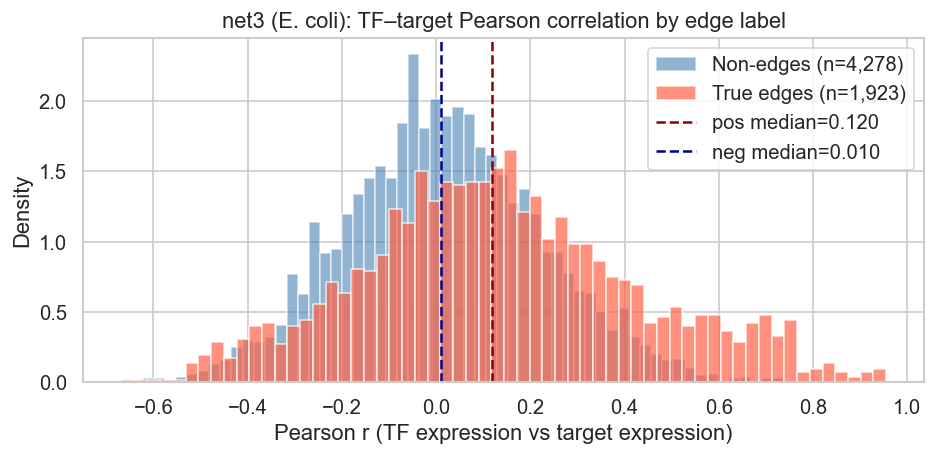

Mann-Whitney U: stat=5132494, p=4.51e-55


In [9]:
# Pearson correlation between each TF and its gold-standard positive targets
# vs random TF–target pairs

pos_edges = gs3[gs3['label'] == 1]
neg_edges = gs3[gs3['label'] == 0]

def edge_correlations(edges, tf_expr, target_expr, max_edges=5000):
    """Compute Pearson r for a sample of TF→target pairs."""
    sample = edges.sample(min(len(edges), max_edges), random_state=42)
    corrs = []
    tf_cols = set(tf_expr.columns)
    tgt_cols = set(target_expr.columns)
    for _, row in sample.iterrows():
        tf, tgt = row['tf'], row['target']
        if tf in tf_cols and tgt in tgt_cols:
            r, _ = stats.pearsonr(tf_expr[tf], target_expr[tgt])
            corrs.append(r)
    return np.array(corrs)

pos_corrs = edge_correlations(pos_edges, tf_expr, target_expr)
neg_corrs = edge_correlations(neg_edges, tf_expr, target_expr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(neg_corrs, bins=60, alpha=0.6, density=True, color='steelblue', label=f'Non-edges (n={len(neg_corrs):,})')
ax.hist(pos_corrs, bins=60, alpha=0.7, density=True, color='tomato',    label=f'True edges (n={len(pos_corrs):,})')
ax.axvline(np.median(pos_corrs), color='darkred',  ls='--', label=f'pos median={np.median(pos_corrs):.3f}')
ax.axvline(np.median(neg_corrs), color='darkblue', ls='--', label=f'neg median={np.median(neg_corrs):.3f}')
ax.set_xlabel('Pearson r (TF expression vs target expression)')
ax.set_ylabel('Density')
ax.set_title('net3 (E. coli): TF–target Pearson correlation by edge label')
ax.legend()
plt.tight_layout()
plt.show()

stat, p = stats.mannwhitneyu(pos_corrs, neg_corrs, alternative='two-sided')
print(f'Mann-Whitney U: stat={stat:.0f}, p={p:.2e}')

## 6. PCA of expression matrices

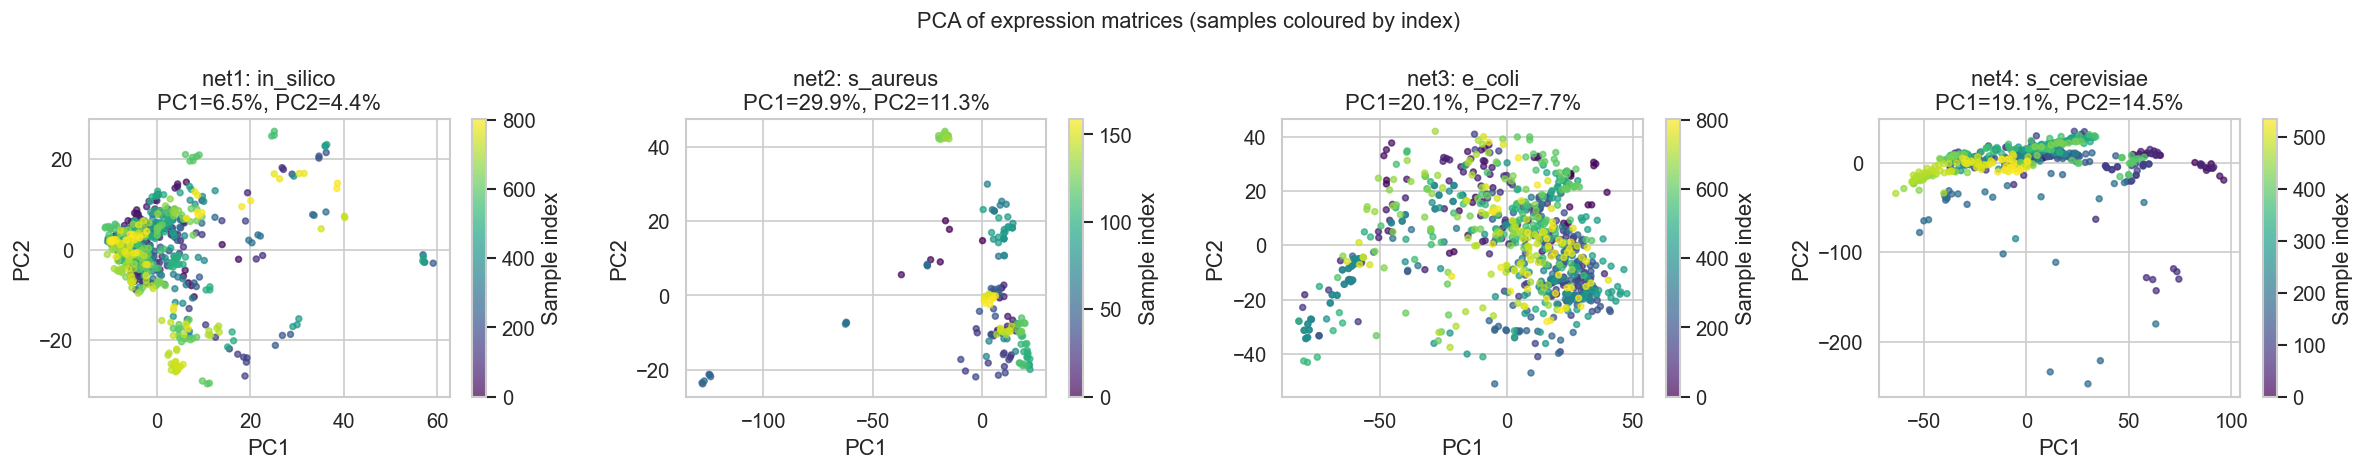

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('PCA of expression matrices (samples coloured by index)', fontsize=13)

for ax, (nid, net) in zip(axes, nets.items()):
    X = StandardScaler().fit_transform(net.expression.values)
    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)
    
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=np.arange(net.n_samples),
                    cmap='viridis', s=12, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Sample index')
    ax.set_title(f'net{nid}: {net.name}\nPC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

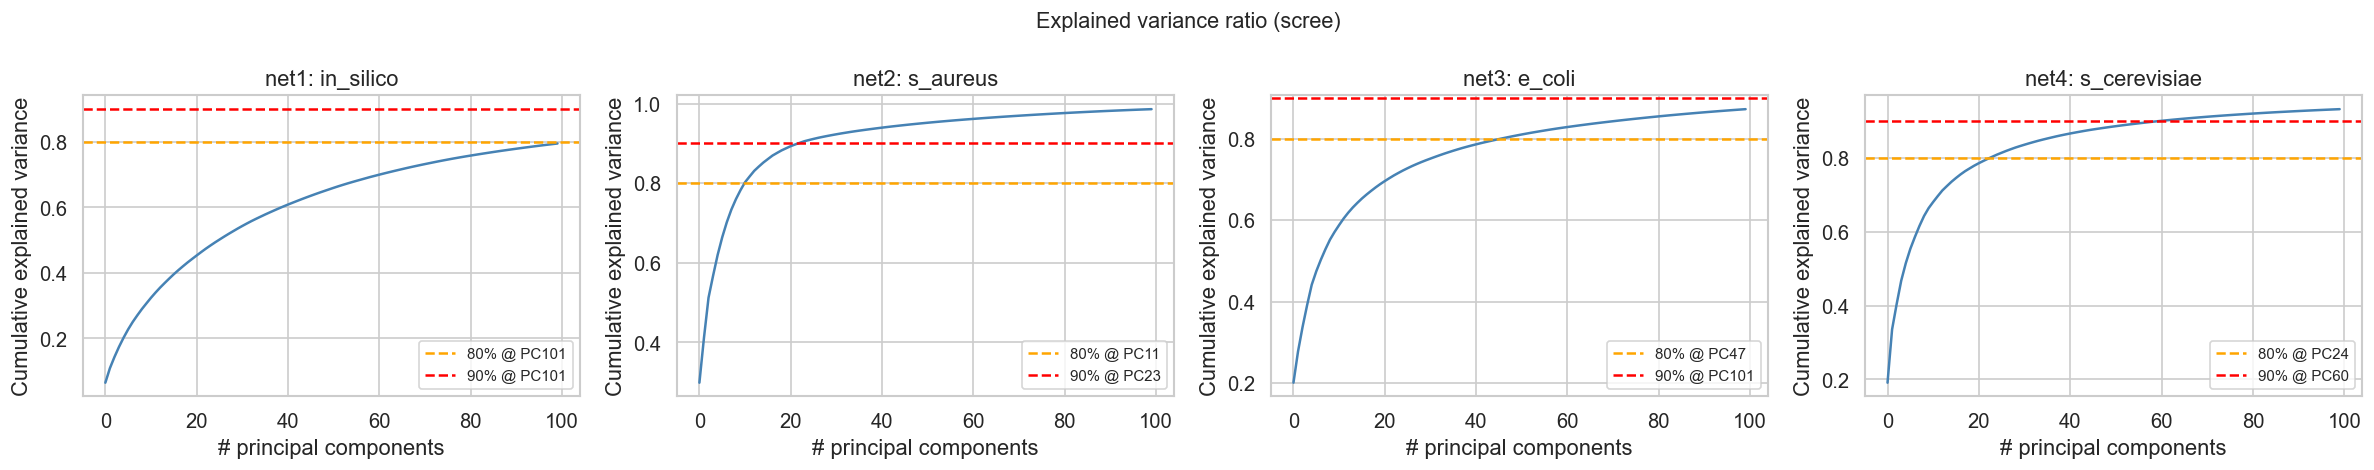

In [11]:
# Scree plots — how many PCs explain 80% / 90% variance?
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Explained variance ratio (scree)', fontsize=13)

for ax, (nid, net) in zip(axes, nets.items()):
    X = StandardScaler().fit_transform(net.expression.values)
    n_comp = min(net.n_samples, net.n_genes, 100)
    pca = PCA(n_components=n_comp)
    pca.fit(X)
    
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    k80 = np.searchsorted(cum_var, 0.80) + 1
    k90 = np.searchsorted(cum_var, 0.90) + 1
    
    ax.plot(cum_var, color='steelblue')
    ax.axhline(0.80, color='orange', ls='--', label=f'80% @ PC{k80}')
    ax.axhline(0.90, color='red',    ls='--', label=f'90% @ PC{k90}')
    ax.set_title(f'net{nid}: {net.name}')
    ax.set_xlabel('# principal components')
    ax.set_ylabel('Cumulative explained variance')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Horseshoe prior sparsity parameter τ₀ estimates

B-JEPA uses the Piironen & Vehtari (2017) formula:

$$\tau_0 = \frac{p_0}{D - p_0} \cdot \frac{\sigma}{\sqrt{n}}$$

where $p_0$ is the expected number of true regulators per gene (5–20), $D$ is the number of TFs, and $n$ is the number of samples.
We set $\sigma = 1$ (standardised expression) and vary $p_0$.

In [12]:
rows = []
for nid, net in nets.items():
    D = net.n_tfs
    n = net.n_samples
    sigma = 1.0  # standardised
    for p0 in [5, 10, 15, 20]:
        tau0 = (p0 / (D - p0)) * (sigma / np.sqrt(n))
        rows.append({'Network': f'net{nid} ({net.name})', 'D (TFs)': D, 'n (samples)': n,
                     'p0': p0, 'tau0': f'{tau0:.4f}'})

tau_df = pd.DataFrame(rows)
tau_df.pivot(index=['Network','D (TFs)','n (samples)'], columns='p0', values='tau0')

,,p0,5,10,15,20
Network,D (TFs),n (samples),,,,
net1 (in_silico),195,805,0.0009,0.0019,0.0029,0.0040
net2 (s_aureus),99,160,0.0042,0.0089,0.0141,0.0200
net3 (e_coli),334,805,0.0005,0.0011,0.0017,0.0022
net4 (s_cerevisiae),333,536,0.0007,0.0013,0.0020,0.0028


## 8. Summary for paper

Key takeaways from EDA:
- **net3 (E. coli) is the primary benchmark**: 805 samples × 4,511 genes, 334 TFs, 2,066 positive edges out of 152,280 evaluated (~1.4% positive rate).
- **Extreme sparsity**: only ~0.14% of all TF→gene pairs are true regulatory edges — exactly the regime where horseshoe priors excel.
- **TF variance**: TFs show slightly different variance profiles than non-TFs (Mann-Whitney p-values above).
- **PCA**: ~30–50 PCs explain 90% of variance across all networks — guides the encoder bottleneck dimension (d_latent=256 is well above this).
- **τ₀ range**: For E. coli (D=334, n=805, p0=10), τ₀ ≈ 0.001 — extremely tight global shrinkage, appropriate for this nearly-null sparse problem.

## 9. GENIE3 baseline results

In [13]:
import json

# Load GENIE3 summary (produced by experiments/exp1_genie3_baseline/run.py)
genie3_summary_path = ROOT / 'results' / 'genie3' / 'summary.json'

with open(genie3_summary_path) as f:
    records = json.load(f)

genie3_df = pd.DataFrame(records).set_index('network')
genie3_df['elapsed_s'] = pd.to_numeric(genie3_df['elapsed_s'], errors='coerce')

display_cols = ['auroc', 'aupr', 'n_samples', 'n_genes', 'n_tfs', 'n_positive_edges', 'elapsed_s']

(
    genie3_df[display_cols]
    .style
    .format({
        'auroc': '{:.4f}',
        'aupr': '{:.4f}',
        'elapsed_s': lambda x: '—' if pd.isna(x) else f'{x:.0f}s',
    })
    .background_gradient(subset=['auroc', 'aupr'], cmap='YlGn')
)

,auroc,aupr,n_samples,n_genes,n_tfs,n_positive_edges,elapsed_s
network,,,,,,,
net1 (in_silico),0.8300,0.2585,805,1643,195,4012,1151s
net2 (s_aureus),0.6778,0.0112,160,2810,99,428,404s
net3 (e_coli),0.6942,0.0993,805,4511,334,2066,2054s
net4 (s_cerevisiae),0.5412,0.0221,536,5950,333,3940,2685s


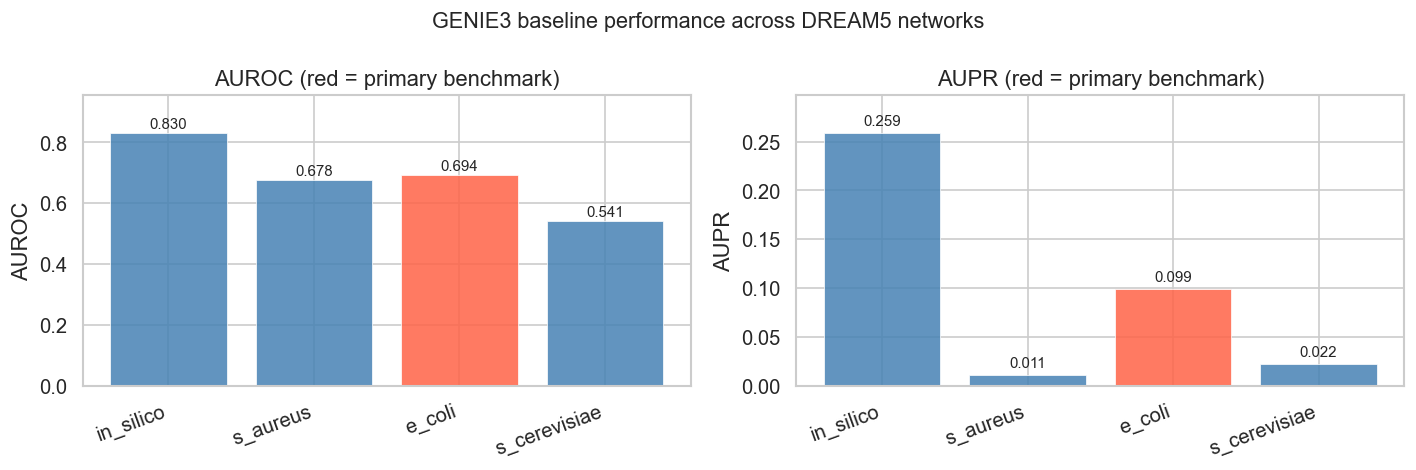

Primary benchmark (net3 E. coli):
  AUROC = 0.6942  ← B-JEPA target to exceed
  AUPR  = 0.0993  ← B-JEPA target to exceed


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('GENIE3 baseline performance across DREAM5 networks', fontsize=13)

networks = genie3_df.index.tolist()
x = np.arange(len(networks))
colors = ['tomato' if 'e_coli' in n else 'steelblue' for n in networks]

for ax, metric, label in zip(axes, ['auroc', 'aupr'], ['AUROC', 'AUPR']):
    vals = genie3_df[metric].values.astype(float)
    bars = ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([n.split('(')[1].rstrip(')') for n in networks], rotation=20, ha='right')
    ax.set_ylabel(label)
    ax.set_title(f'{label} (red = primary benchmark)')
    ax.set_ylim(0, float(np.nanmax(vals)) * 1.15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Use .contains() so this doesn't break if the exact key string ever changes
ecoli_row = genie3_df[genie3_df.index.str.contains('e_coli')].iloc[0]
print('Primary benchmark (net3 E. coli):')
print(f"  AUROC = {ecoli_row['auroc']:.4f}  ← B-JEPA target to exceed")
print(f"  AUPR  = {ecoli_row['aupr']:.4f}  ← B-JEPA target to exceed")